In [ ]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('/datasets/rest_data_us_upd.csv')

# Visualização rápida para confirmar o carregamento
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


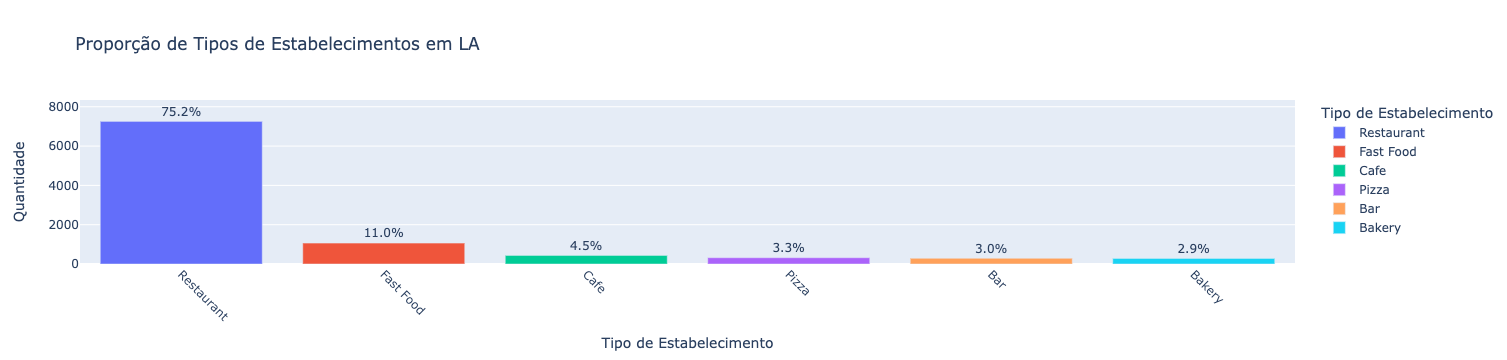

In [ ]:


import plotly.express as px

# 1. Contando a frequência de cada tipo de estabelecimento
type_proportions = df['object_type'].value_counts().reset_index()
type_proportions.columns = ['object_type', 'count']

# 2. Calculando a proporção (valor relativo) - Teoria da Sprint 10
total_establishments = type_proportions['count'].sum()
type_proportions['percentage'] = (type_proportions['count'] / total_establishments) * 100

# 3. Construindo o gráfico
fig = px.bar(
    type_proportions,
    x='object_type',
    y='count',
    text=type_proportions['percentage'].apply(lambda x: f'{x:.1f}%'),
    title='Proporção de Tipos de Estabelecimentos em LA',
    labels={'object_type': 'Tipo de Estabelecimento', 'count': 'Quantidade'},
    color='object_type'
)

# Ajustando o layout para melhor legibilidade
fig.update_xaxes(tickangle=45)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_range=[0, type_proportions['count'].max() * 1.15])
fig.show()



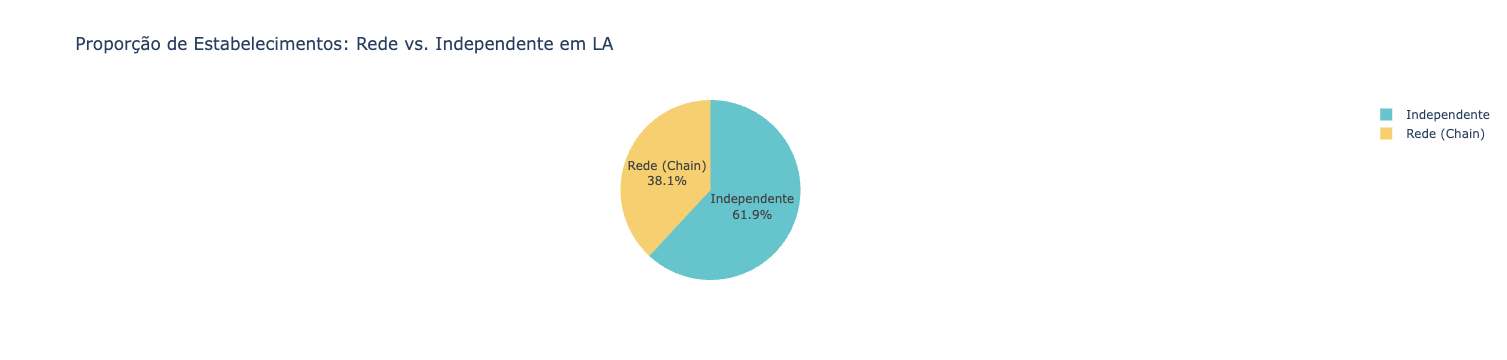

In [ ]:
# Passo 2 - 2

# 1. Contando os estabelecimentos de rede vs. não rede
chain_counts = df['chain'].value_counts().reset_index()
chain_counts.columns = ['is_chain', 'count']

# 2. Mapeando os valores para nomes mais legíveis no gráfico
chain_counts['is_chain'] = chain_counts['is_chain'].map({True: 'Rede (Chain)', False: 'Independente'})

# 3. Construindo o gráfico de pizza
fig = px.pie(
    chain_counts,
    values='count',
    names='is_chain',
    title='Proporção de Estabelecimentos: Rede vs. Independente em LA',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Adicionando interatividade e detalhes (Teoria Plotly)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

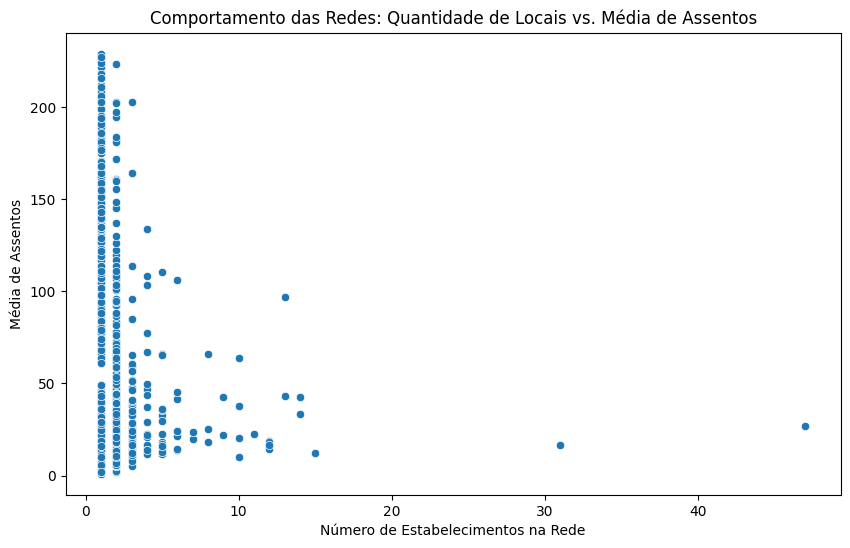


Tipos de estabelecimentos mais comuns para redes:
Restaurant    2292
Fast Food      605
Bakery         283
Cafe           266
Pizza          153
Bar             77
Name: object_type, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Limpeza de Dados
# Como são apenas 3 valores em 9600, podemos descartar ou preencher.
df_clean = df.dropna(subset=['chain'])

# 2. Filtrando apenas as redes para análise de comportamento
chains_only = df_clean[df_clean['chain'] == True]

# 3. Agrupando para ver a característica das redes (Teoria: Agrupamento)
# Ver quantos estabelecimentos cada rede tem e a média de assentos
chain_behavior = chains_only.groupby('object_name').agg({
    'id': 'count',
    'number': 'mean'
}).reset_index()
chain_behavior.columns = ['object_name', 'total_establishments', 'avg_seats']

# 4. Visualização de Dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_establishments', y='avg_seats', data=chain_behavior)
plt.title('Comportamento das Redes: Quantidade de Locais vs. Média de Assentos')
plt.xlabel('Número de Estabelecimentos na Rede')
plt.ylabel('Média de Assentos')
plt.show()
print()

# Filtrando apenas os estabelecimentos que são redes
chains = df[df['chain'] == True]

# Contando qual tipo de estabelecimento aparece mais vezes como rede
typical_chain = chains['object_type'].value_counts()

print("Tipos de estabelecimentos mais comuns para redes:")
print(typical_chain)

In [ ]:
# 1. Calculando a quantidade total por tipo
total_types = df_clean['object_type'].value_counts()

# 2. Calculando a quantidade de redes por tipo (o que você já fez)
chain_types = df_clean[df_clean['chain'] == True]['object_type'].value_counts()

# 3. Criando a proporção relativa (Teoria da Sprint 10)
proportion = (chain_types / total_types).sort_values(ascending=False)

print("Proporção de Redes por Tipo (Market Share de Redes):")
print(proportion)

Proporção de Redes por Tipo (Market Share de Redes):
Bakery        1.000000
Cafe          0.611494
Fast Food     0.567542
Pizza         0.479624
Restaurant    0.316007
Bar           0.263699
Name: object_type, dtype: float64


- O estabelecimento típico para redes (onde a presença de "Chain = True" é proporcionalmente dominante) é a "Bakery".
- A partir do gráfico de dispersão, as redes em LA seguem o padrão de muitos locais com poucos assentos (como cafeterias e fast food de balcão) ou poucos locais com muitos assentos (restaurantes de grande porte com poucas filiais).


Média de assentos por tipo:
  object_type  avg_seats
0  Restaurant  48.042316
1         Bar  44.767123
2   Fast Food  31.837711
3       Pizza  28.459375
4        Cafe  25.000000
5      Bakery  21.773852



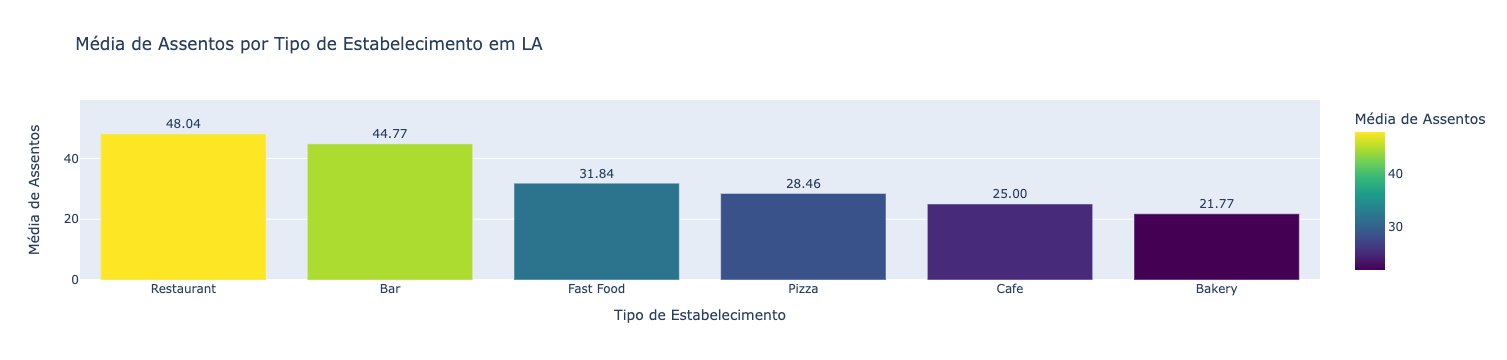

In [ ]:
import plotly.express as px
# Calculando a média de assentos por tipo de estabelecimento
avg_seats = df.groupby('object_type')['number'].mean().sort_values(ascending=False).reset_index()
avg_seats.columns = ['object_type', 'avg_seats']

# 2. Identificando o líder em capacidade
print("Média de assentos por tipo:")
print(avg_seats)
print()

# Criando o gráfico de barras corrigido
fig = px.bar(
    avg_seats,
    x='object_type',
    y='avg_seats',
    # Passamos os valores formatados diretamente para o argumento text
    text=avg_seats['avg_seats'].apply(lambda x: f'{x:.2f}'),
    title='Média de Assentos por Tipo de Estabelecimento em LA',
    labels={'object_type': 'Tipo', 'avg_seats': 'Média de Assentos'},
    color='avg_seats',
    color_continuous_scale='Viridis'
)

fig.update_traces(textposition='outside')

# Refinando o layout
fig.update_layout(
    xaxis_title="Tipo de Estabelecimento",
    yaxis_title="Média de Assentos",
    xaxis={'categoryorder':'total descending'},
    yaxis_range=[0, top_10_streets['count'].max() * 1/5]
)

fig.show()

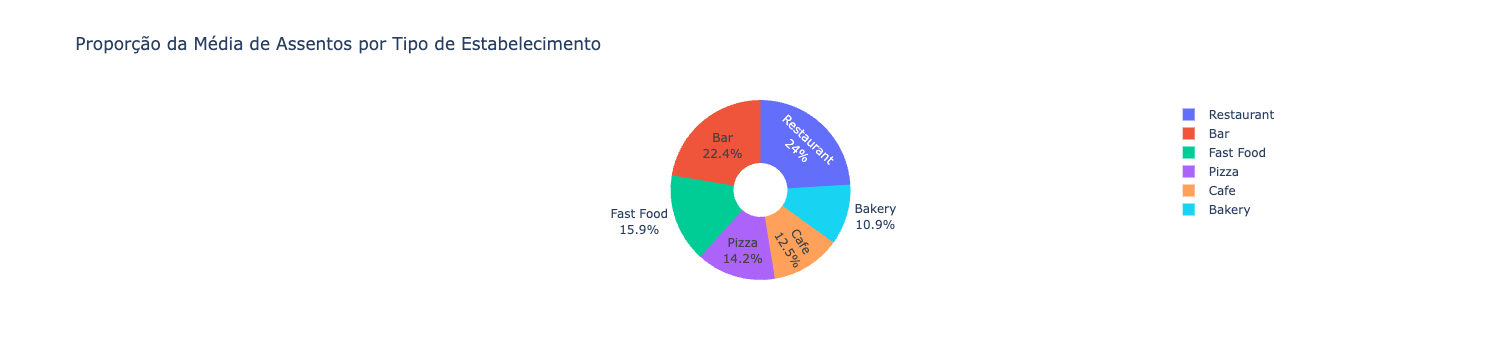

In [ ]:
import plotly.express as px

# Criando um gráfico de pizza interativo (Ensinado na Sprint)
fig = px.pie(
    avg_seats,
    values='avg_seats',
    names='object_type',
    title='Proporção da Média de Assentos por Tipo de Estabelecimento',
    hole=0.3
)

# Refinando as informações ao passar o mouse (Interatividade da Sprint)
fig.update_traces(textinfo='percent+label')

fig.show()

In [ ]:
# Extraindo o nome da rua (pulando o primeiro elemento que é o número)
# n=1 limita a divisão no primeiro espaço; expand=True permite acessar os elementos
df['street_name'] = df['address'].str.split(' ', n=1).str[1]

# 2. Verificação direta
print(df[['address', 'street_name']].head())

                   address         street_name
0   3708 N EAGLE ROCK BLVD   N EAGLE ROCK BLVD
1        100 WORLD WAY 120       WORLD WAY 120
2  6801 HOLLYWOOD BLVD 253  HOLLYWOOD BLVD 253
3       1814 W SUNSET BLVD       W SUNSET BLVD
4       2100 ECHO PARK AVE       ECHO PARK AVE


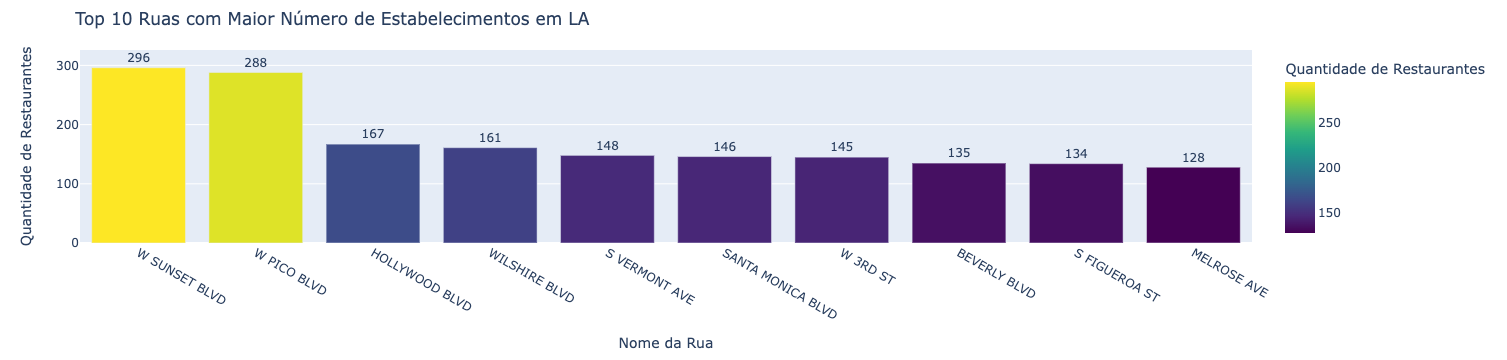

In [ ]:
# Contando a frequência de estabelecimentos por rua e pegando o Top 10
top_10_streets = df['street_name'].value_counts().reset_index().head(10)
top_10_streets.columns = ['street_name', 'count']

# Criando o gráfico de barras interativo
fig = px.bar(
    top_10_streets,
    x='street_name',
    y='count',
    title='Top 10 Ruas com Maior Número de Estabelecimentos em LA',
    labels={'street_name': 'Nome da Rua', 'count': 'Quantidade de Restaurantes'},
    text='count',
    color='count',
    color_continuous_scale='Viridis'
)

# Ajustando o posicionamento do texto e layout
fig.update_traces(textposition='outside')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.update_layout(margin=dict(t=50))
fig.update_yaxes(range=[0, top_10_streets['count'].max() + 30])
fig.show()

In [ ]:
# Contando a frequência de estabelecimentos por nome de rua
street_counts = df['street_name'].value_counts()

# Filtrando apenas as ruas onde a contagem é exatamente igual a 1
single_restaurant_streets = street_counts[street_counts == 1]

# Calculando o total
total_single_streets = len(single_restaurant_streets)

print(f"Total de ruas com apenas um estabelecimento: {total_single_streets}")

Total de ruas com apenas um estabelecimento: 2450


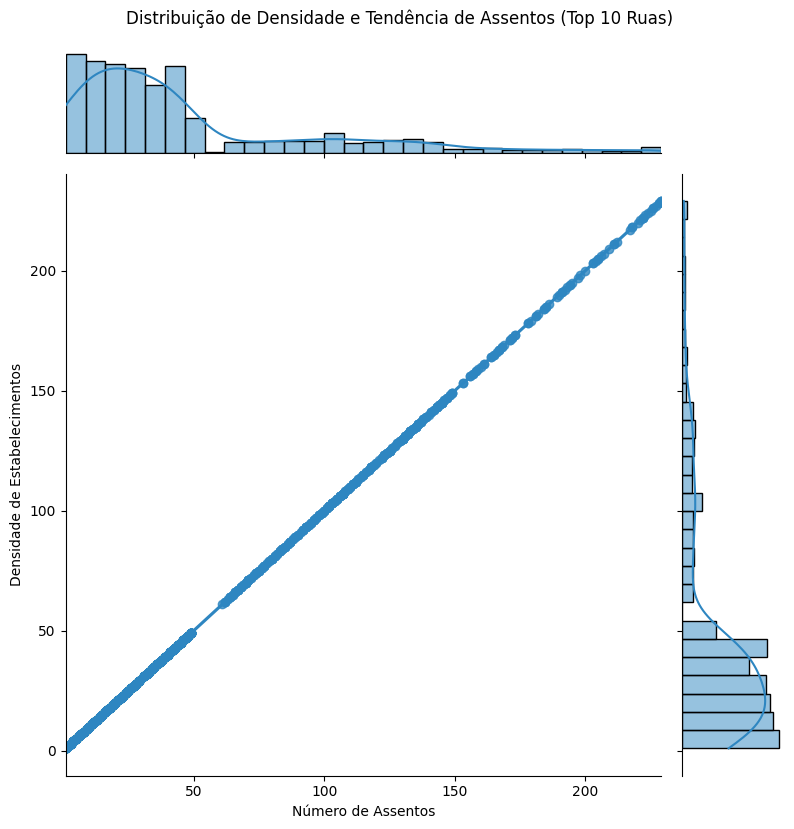

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Preparando os dados das Top 10 ruas
top_10_names = top_10_streets['street_name']
df_top_10 = df[df['street_name'].isin(top_10_names)]

#  Criando o Jointplot com regressão e densidade
g = sns.jointplot(
    data=df_top_10,
    x="number",
    y="number", # Analisando a densidade da própria variável de assentos
    kind="reg",
    color="#2E86C1",
    height=8,
    marginal_kws=dict(bins=30, fill=True)
)

# Refinando a apresentação
g.fig.suptitle("Distribuição de Densidade e Tendência de Assentos (Top 10 Ruas)", y=1.03)
g.set_axis_labels("Número de Assentos", "Densidade de Estabelecimentos")

plt.show()

O gráfico de Distribuição de Densidade e Tendências de Assentos, nos mostra algumas conclusões:

- A imensa maioria dos estabelecimentos opera com menos de 50 assentos. Isso indica que o modelo de negócio predominante nessas áreas de alto tráfego prioriza o giro rápido de clientes em vez de longos períodos de permanência;
- Existe uma queda abrupta na densidade logo após a marca de 50 lugares. Isso sugere um limite de eficiência operacional. Manter um estabelecimento com capacidade superior a essa em ruas de alto custo (como a Sunset Blvd ou Wilshire Blvd) parece ser uma exceção estatística;
- A linha de regressão evidencia que, embora existam pontos que se estendem até 200 assentos, eles são numericamente irrelevantes perto da massa de dados concentrada no início do gráfico. Investir em um local com muitos assentos nessas ruas seria nadar contra a corrente estatística do que o mercado local valida.

A análise dos dados de Los Angeles mostra que o mercado gastronômico nas regiões mais movimentadas é focado em eficiência e alta rotatividade. O tipo mais apropriado de estabelecimento para um novo investimento é um local de pequeno porte, preferencialmente uma cafeteria ou um restaurante de serviço rápido. Os dados deixam claro que a grande maioria dos negócios de sucesso nessas áreas opera com uma capacidade entre 20 e 40 assentos. Ter um espaço maior do que isso em ruas de alto fluxo, como a Sunset Blvd ou a Pico Blvd, é um risco desnecessário, já que o custo do aluguel é muito alto e a tendência do mercado local valida espaços menores e mais ágeis.

Sobre a possibilidade de desenvolver uma rede, os dados indicam que esse é um caminho muito viável e estratégico. Como a maioria dos estabelecimentos nessas ruas populares é pequena, é muito mais fácil replicar um modelo de negócio enxuto e padronizado em diferentes pontos da cidade do que tentar manter uma única unidade gigante. Criar uma rede permite que você marque presença em várias dessas ruas do "Top 10" ao mesmo tempo, diluindo os riscos e aproveitando o fluxo constante de pessoas em diferentes bairros. O segredo para LA, a partir dos dados disponibilizados, é pensar pequeno no tamanho de cada loja, mas grande na quantidade de unidades espalhadas pela cidade.

Apresentação: <https://drive.google.com/file/d/1xBtaEwnDEfSulNzWBFLa_0WbIVzgt5s-/view?usp=sharing>